In [13]:
import torch
import pyro
import pyro.distributions as dist
from pyro.infer import SVI, Trace_ELBO
from pyro.optim import Adam
import matplotlib.pyplot as plt
import numpy as np

In [14]:
X = torch.linspace(0, 10, 100)
true_w, true_b = 2.5, 1.0
y = true_w * X + true_b + torch.randn(100) * 1.5

True scatter


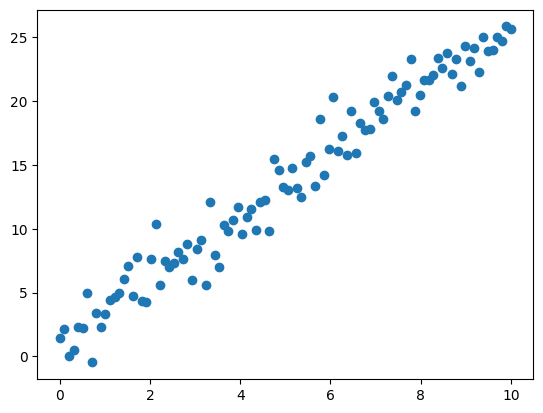

In [15]:
print("True scatter")
plt.scatter(X, y)

In [16]:
def model(X, y):
    w = pyro.sample('w', dist.Normal(0., 10.))
    b = pyro.sample('b', dist.Normal(0., 10.))

    sigma = pyro.sample('sigma', dist.LogNormal(0., 1.))
    mean = w * X + b

    with pyro.plate('data', len(X)):
        pyro.sample('obs', dist.Normal(mean, sigma), obs=y)

In [17]:
def guide(X, y):
    # Instead of fixed values, we learn the SHAPE of the posterior
    # Each parameter gets its own mean and std that SVI will optimize

    w_loc   = pyro.param("w_loc",   torch.tensor(0.))
    w_scale = pyro.param("w_scale", torch.tensor(1.),
                         constraint=dist.constraints.positive)

    b_loc   = pyro.param("b_loc",   torch.tensor(0.))
    b_scale = pyro.param("b_scale", torch.tensor(1.),
                         constraint=dist.constraints.positive)

    sigma_loc   = pyro.param("sigma_loc",   torch.tensor(0.))
    sigma_scale = pyro.param("sigma_scale", torch.tensor(0.5),
                             constraint=dist.constraints.positive)

    # Sample from our approximate posterior
    pyro.sample("w",     dist.Normal(w_loc,   w_scale))
    pyro.sample("b",     dist.Normal(b_loc,   b_scale))
    pyro.sample("sigma", dist.LogNormal(sigma_loc, sigma_scale))

In [18]:
pyro.clear_param_store()
svi = SVI(model, guide, Adam({"lr": 0.005}), loss=Trace_ELBO())

losses = []
for step in range(10000):
    loss = svi.step(X, y)
    losses.append(loss)
    if (step + 1) % 500 == 0:
        print(f"Step {step+1} | Loss: {loss:.3f}")

# ── What we learned: distributions, not numbers ───────────────────────────────
w_loc   = pyro.param("w_loc").item()
w_scale = pyro.param("w_scale").item()
b_loc   = pyro.param("b_loc").item()
b_scale = pyro.param("b_scale").item()

print(f"\nw: mean={w_loc:.3f}, std={w_scale:.3f}  (true: {true_w})")
print(f"b: mean={b_loc:.3f}, std={b_scale:.3f}  (true: {true_b})")

Step 500 | Loss: 10408.016
Step 1000 | Loss: 2267.684
Step 1500 | Loss: 302.755
Step 2000 | Loss: 274.276
Step 2500 | Loss: 271.232
Step 3000 | Loss: 240.255
Step 3500 | Loss: 240.167
Step 4000 | Loss: 201.105
Step 4500 | Loss: 205.380
Step 5000 | Loss: 285.241
Step 5500 | Loss: 245.085
Step 6000 | Loss: 230.094
Step 6500 | Loss: 249.534
Step 7000 | Loss: 223.358
Step 7500 | Loss: 223.465
Step 8000 | Loss: 251.617
Step 8500 | Loss: 189.624
Step 9000 | Loss: 214.473
Step 9500 | Loss: 192.879
Step 10000 | Loss: 202.594

w: mean=2.494, std=0.067  (true: 2.5)
b: mean=1.073, std=0.176  (true: 1.0)


In [ ]:
def predict(X_new, num_samples=1000):
    """
    Instead of one prediction line, we get num_samples plausible lines.
    Each sample draws a different (w, b) from the posterior.
    """
    X_new_t = torch.tensor(X_new, dtype=torch.float32)
    predictions = []

    for _ in range(num_samples):
        # Sample a plausible w and b from the learned posterior
        w_sample     = dist.Normal(w_loc, w_scale).sample()
        b_sample     = dist.Normal(b_loc, b_scale).sample()
        sigma_sample = dist.LogNormal(
            pyro.param("sigma_loc"),
            pyro.param("sigma_scale")
        ).sample()

        # Each sample gives a slightly different prediction line
        y_pred = w_sample * X_new_t + b_sample
        # Add observation noise
        y_pred_noisy = dist.Normal(y_pred, sigma_sample).sample()
        predictions.append(y_pred_noisy.numpy())

    return np.array(predictions)


In [20]:
X_new  = np.linspace(-2, 12, 200)   # predict beyond training data range
preds  = predict(X_new)

mean_pred = preds.mean(axis=0)
lower_95  = np.percentile(preds,  2.5, axis=0)
upper_95  = np.percentile(preds, 97.5, axis=0)
lower_50  = np.percentile(preds, 25,   axis=0)
upper_50  = np.percentile(preds, 75,   axis=0)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Bayesian vs Classical Linear Regression", fontsize=13, fontweight="bold")

# Left: posterior predictive with uncertainty bands
axes[0].scatter(X.numpy(), y.numpy(), alpha=0.4, s=20, label="Data", color="steelblue")
axes[0].plot(X_new, mean_pred, color="red", linewidth=2, label="Posterior mean")
axes[0].fill_between(X_new, lower_95, upper_95, alpha=0.15, color="red", label="95% CI")
axes[0].fill_between(X_new, lower_50, upper_50, alpha=0.3,  color="red", label="50% CI")
axes[0].axvline(0,  color="gray", linestyle="--", alpha=0.5)
axes[0].axvline(10, color="gray", linestyle="--", alpha=0.5)
axes[0].set_title("Predictions with Uncertainty\n(grey lines = data boundary)")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# Middle: posterior distribution over w
w_samples = dist.Normal(w_loc, w_scale).sample((5000,)).numpy()
axes[1].hist(w_samples, bins=60, density=True, color="steelblue", alpha=0.7)
axes[1].axvline(true_w, color="red",   linewidth=2, label=f"True w={true_w}")
axes[1].axvline(w_loc,  color="green", linewidth=2, linestyle="--",
                label=f"Posterior mean={w_loc:.3f}")
axes[1].set_title("Posterior over w\n(what we believe about the slope)")
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

# Right: posterior distribution over b
b_samples = dist.Normal(b_loc, b_scale).sample((5000,)).numpy()
axes[2].hist(b_samples, bins=60, density=True, color="steelblue", alpha=0.7)
axes[2].axvline(true_b, color="red",   linewidth=2, label=f"True b={true_b}")
axes[2].axvline(b_loc,  color="green", linewidth=2, linestyle="--",
                label=f"Posterior mean={b_loc:.3f}")
axes[2].set_title("Posterior over b\n(what we believe about the intercept)")
axes[2].legend(fontsize=8)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("bayesian_regression.png", dpi=150)
plt.show()

AttributeError: 'NoneType' object has no attribute 'mean'